In [1]:
# %% [markdown]
# # ML4Sci GSoC 2026: Common Test I - Multi-Class Classification
# **Author:** Kartik Chavan  
# *Task:** Classify gravitational lensing images into three distinct substructure categories: No Substructure, Sphere, and Vortex.
# **Architecture:** ResNet18 (via `timm`) - *Adapted for 1-channel grayscale astrophysics data to ensure stable convergence.*
import sys
import os
sys.path.append(os.path.abspath(".."))
import torch
import torch.nn as nn
import torch.optim as optim
from src.data_loader import get_dataloaders
from src.models import get_model
from src.train import train_one_epoch, validate
from src.metrics import compute_metrics
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
import timm
import torch.nn as nn
import torch.optim as optim

# Hyperparameters
DATA_DIR = "../data/raw/Task_I_Classification"
BATCH_SIZE = 64
EPOCHS = 15
LEARNING_RATE = 1e-3

train_loader, val_loader = get_dataloaders(DATA_DIR, batch_size=BATCH_SIZE)

# Initialize ResNet18, adapted for 1-channel (grayscale) lensing data
model = timm.create_model('resnet18', pretrained=True, in_chans=1, num_classes=3).to(device)

criterion = nn.CrossEntropyLoss()

# Optimizer and learning rate scheduler for smooth convergence
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-2)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print(f"Model initialized on: {device}")

Model initialized on: cuda


In [3]:
# Grabbing one batch of data
images, labels = next(iter(train_loader))

print(f"Image batch shape: {images.shape}")
print(f"Maximum pixel value: {images.max().item():.6f}")
print(f"Minimum pixel value: {images.min().item():.6f}")
print(f"Mean pixel value: {images.mean().item():.6f}")

Image batch shape: torch.Size([64, 1, 150, 150])
Maximum pixel value: 1.000000
Minimum pixel value: 0.000000
Mean pixel value: 0.060483


In [4]:
import os

os.makedirs("../models", exist_ok=True)
save_path = "../models/common_task_resnet18.pth"

history = {'train_loss': [], 'val_loss': []}
best_val_loss = float('inf') # Setting initial best loss to infinity

print("Starting Professional Training Loop...")

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_labels, val_probs = validate(model, val_loader, criterion, device)
    
    scheduler.step()
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    
    # Only saving if the model actually improved
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), save_path)
        save_msg = f" (New Best Model Saved!)"
    else:
        save_msg = ""
        
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}{save_msg}")

print(f"Training Complete! Best weights are securely saved at: {save_path}")

Starting Professional Training Loop...


Validating: 100%|████████████████████████████████████████████████████████████████████| 118/118 [00:42<00:00,  2.79it/s]


Epoch 01/15 | Train Loss: 0.9994 | Val Loss: 1.0273 (New Best Model Saved!)


Validating: 100%|████████████████████████████████████████████████████████████████████| 118/118 [00:38<00:00,  3.04it/s]


Epoch 02/15 | Train Loss: 0.6108 | Val Loss: 0.5164 (New Best Model Saved!)


...

Epoch 13/15 | Train Loss: 0.1482 | Val Loss: 0.1666 (New Best Model Saved!)


Validating: 100%|████████████████████████████████████████████████████████████████████| 118/118 [00:42<00:00,  2.77it/s]


Epoch 14/15 | Train Loss: 0.1408 | Val Loss: 0.1591 (New Best Model Saved!)


Validating: 100%|████████████████████████████████████████████████████████████████████| 118/118 [00:43<00:00,  2.73it/s]

Epoch 15/15 | Train Loss: 0.1357 | Val Loss: 0.1575 (New Best Model Saved!)
Training Complete! Best weights are securely saved at: ../models/common_task_resnet18.pth


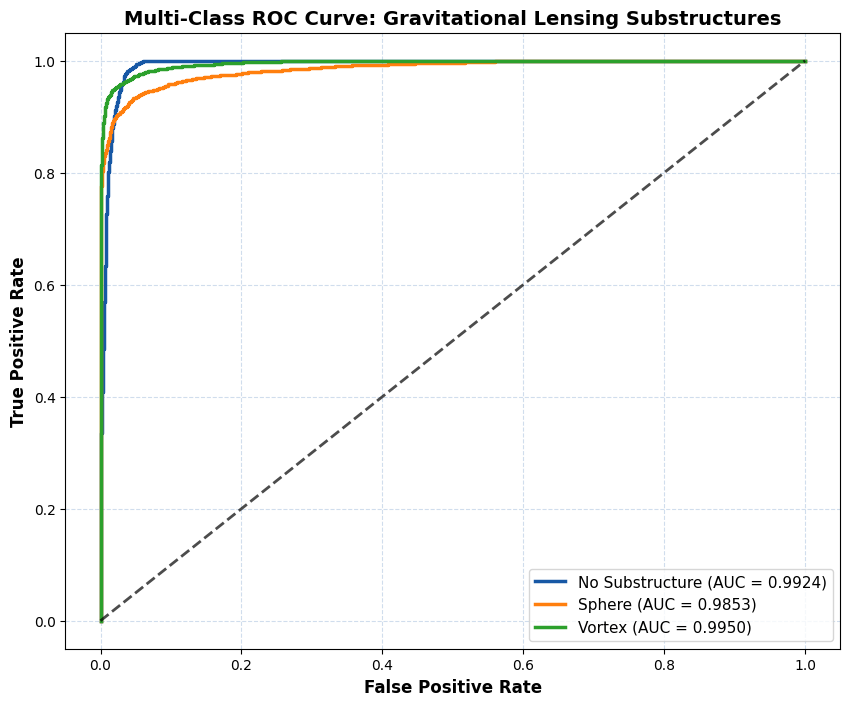

In [6]:
import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

def compute_metrics_safe(y_true, y_probs, class_names):
    plt.figure(figsize=(10, 8))
    auc_scores = {}
    
    # We'll use a clean palette for the classes
    colors = ['#1758A5', '#FF7F0E', '#2CA02C'] 
    
    for i, (class_name, color) in enumerate(zip(class_names, colors)):
        y_binary = (np.array(y_true) == i).astype(int)
        y_score = np.array(y_probs)[:, i]
        
        fpr, tpr, _ = roc_curve(y_binary, y_score)
        roc_auc = auc(fpr, tpr)
        auc_scores[class_name] = roc_auc
        
        plt.plot(fpr, tpr, color=color, linewidth=2.5, label=f'{class_name} (AUC = {roc_auc:.4f})')

    plt.plot([0, 1], [0, 1], 'k--', linewidth=2, alpha=0.7)
    plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
    plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
    plt.title('Multi-Class ROC Curve: Gravitational Lensing Substructures', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=11)
    plt.grid(alpha=0.2, color='#1758A5', linestyle='--')
    
    plt.savefig('roc_curve.png', dpi=300, bbox_inches='tight') 
    plt.show()
    
    return auc_scores

# defining the target labels explicitly for the metric calculation
class_names = ['No Substructure', 'Sphere', 'Vortex']

# executing the ROC curve generation
auc_scores = compute_metrics_safe(val_labels, val_probs, class_names)

Visualizing Validation Predictions...


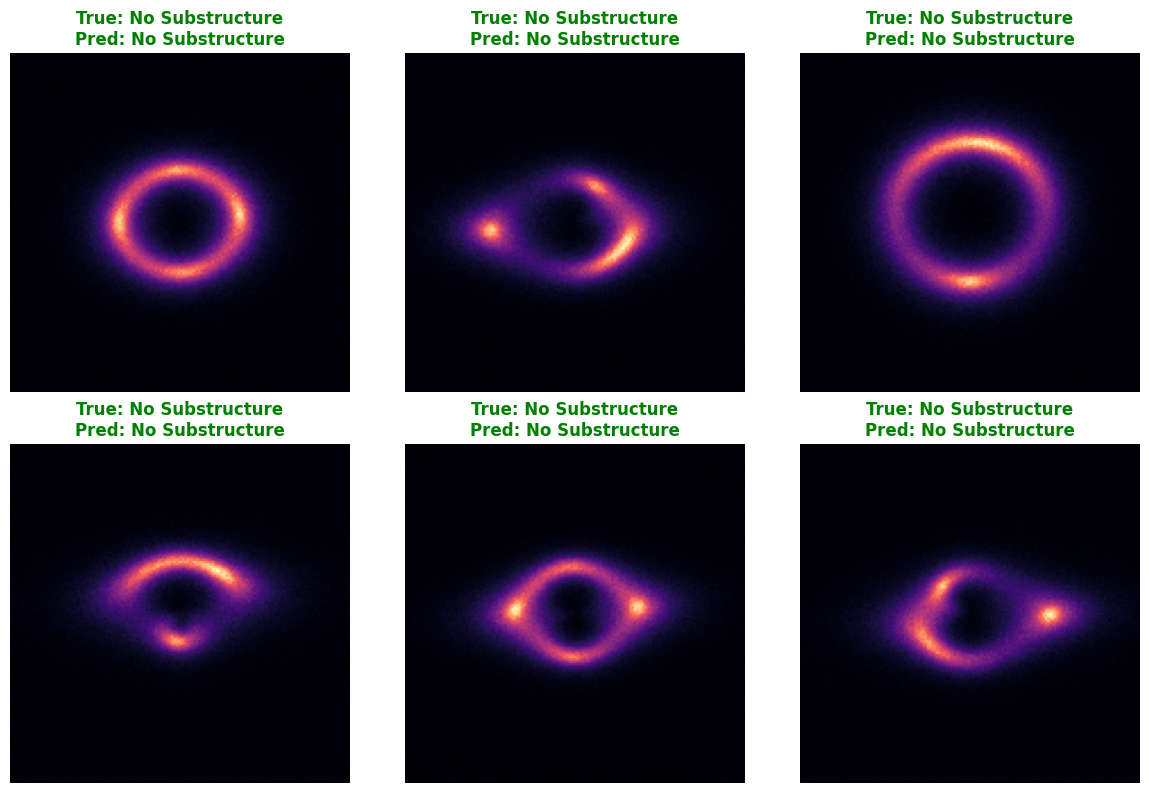

In [7]:
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt

def visualize_predictions(model, dataloader, class_names, device, num_images=6):
    model.eval()
    # Grabbing one batch of validation data
    images, labels = next(iter(dataloader))
    images, labels = images.to(device), labels.to(device)
    
    with torch.no_grad():
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        
    # Moving to CPU and format for matplotlib
    images = images.cpu().squeeze().numpy() 
    labels = labels.cpu().numpy()
    preds = preds.cpu().numpy()
    
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.flatten()
    
    for i in range(min(num_images, len(images))):
        # 'magma' colormap is standard for astrophysical data (thats why I'm using it for visualization)
        axes[i].imshow(images[i], cmap='magma') 
        
        true_label = class_names[labels[i]]
        pred_label = class_names[preds[i]]
        
        color = 'green' if true_label == pred_label else 'red'
        axes[i].set_title(f"True: {true_label}\nPred: {pred_label}", color=color, fontweight='bold')
        axes[i].axis('off')
        
    plt.tight_layout()
    plt.show()

# Running it!
print("Visualizing Validation Predictions...")
visualize_predictions(model, val_loader, class_names, device)